# Decision Tree Regression

## Main Math for Decision Tree Regression

Decision tree regression divides the input space into regions using a sequence of splitting rules. Each final region, called a **leaf**, predicts a constant value.

- $x$: input variable, or input vector when there are multiple features.
- $y$: actual output.
- $\hat{y}$: predicted output.
- $n$: number of training observations.
- $M$: number of leaves.

The equations below describe a regression tree fitted using **squared-error loss**.

### 1. The regression equation

Simple linear regression predicts using a straight line:

$$
\hat{y} = b_0 + b_1x
$$

Decision tree regression predicts using the region containing the input:

$$
\hat{y}(x)
=
\sum_{m=1}^{M}c_m\,\mathbf{1}(x\in R_m)
$$

- **$R_m$:** input region corresponding to leaf $m$.
- **$c_m$:** constant prediction for that leaf.
- **$\mathbf{1}(x\in R_m)$:** equals 1 if $x$ belongs to $R_m$, and 0 otherwise.

Each input belongs to exactly one leaf. For example, a tree with one split at $s$ predicts:

$$
\hat{y}(x)=
\begin{cases}
c_1, & x\leq s,\\
c_2, & x>s.
\end{cases}
$$

The resulting prediction function is **piecewise constant**: it stays constant within each leaf and can change at a boundary.

### 2. Residuals: prediction errors

For training observation $i$:

$$
e_i=y_i-\hat{y}_i
$$

If observation $i$ belongs to leaf $m$, then:

$$
e_i=y_i-c_m
$$

A positive residual means the model underestimates the output; a negative residual means it overestimates the output.

As in the earlier least-squares models, the total squared error is:

$$
\mathrm{SSE}
=
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

### 3. Finding the best-fitting model

The tree is built by repeatedly choosing splits that reduce squared error.

At a node containing training observations indexed by $I$, a candidate split uses feature $j$ and threshold $s$:

$$
I_L(j,s)=\{i\in I:x_{ij}\leq s\}
$$

$$
I_R(j,s)=\{i\in I:x_{ij}>s\}
$$

Here, $x_{ij}$ is the value of feature $j$ for observation $i$. With one input, this is simply $x_i$.

For each candidate split, calculate the mean output in each child:

$$
\bar{y}_L=\frac{1}{|I_L|}\sum_{i\in I_L}y_i,
\qquad
\bar{y}_R=\frac{1}{|I_R|}\sum_{i\in I_R}y_i
$$

Then choose the valid split minimizing:

$$
(j^*,s^*)
=
\arg\min_{j,s}
\left[
\sum_{i\in I_L(j,s)}(y_i-\bar{y}_L)^2
+
\sum_{i\in I_R(j,s)}(y_i-\bar{y}_R)^2
\right]
$$

The process repeats within the child nodes until a stopping condition is reached.

This is a **greedy procedure**: it chooses the best available split at each node, without guaranteeing the globally best tree.

### 4. Calculating the leaf predictions

Once the regions are fixed, the prediction for leaf $m$ is the mean of its training outputs:

$$
c_m
=
\frac{1}{n_m}
\sum_{i:x_i\in R_m}y_i
$$

Here, $n_m$ is the number of training observations in that leaf.

The mean is used because it minimizes squared error within the leaf:

$$
c_m
=
\arg\min_c
\sum_{i:x_i\in R_m}(y_i-c)^2
$$

For example, if a leaf contains outputs $10,12,14$, its prediction is:

$$
c_m=\frac{10+12+14}{3}=12
$$

Every new input reaching that leaf receives the prediction $12$.

Tree complexity is controlled through settings such as maximum depth and minimum observations per leaf. Deeper trees can capture more detail but may overfit. These settings can be selected using validation data or cross-validation.

Unlike the coefficients in linear and polynomial regression, the learned parameters here are the **splitting rules and leaf predictions**.

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

## Training the Decision Tree Regression model on the whole dataset

In [3]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=0)
regressor.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with 

## Predicting a new result

In [4]:
regressor.predict([[6.5]])

array([150000.])

## Visualising the Decision Tree Regression results (higher resolution)

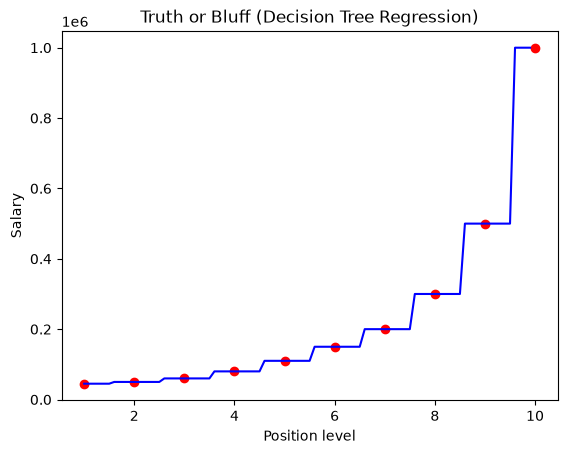

In [5]:
X_grid = np.arange(X.min(), X.max(), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color='red')
plt.plot(X_grid, regressor.predict(X_grid), color='blue')
plt.title('Truth or Bluff (Decision Tree Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()